# ODMR vs lock-in signal overlay

This notebook overlays the ODMR MW-on signal curve with the parked lock-in `signal_ADC` points from a multipoint CSV.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_project_root():
    roots = [Path.cwd(), *Path.cwd().parents]
    for root in roots:
        for candidate in (root, root / "nv_magnetometer_project"):
            if (candidate / "data" / "odmr_sweeps").exists() and (candidate / "data" / "lockin_multipoint").exists():
                return candidate.resolve()
    raise FileNotFoundError("Could not find nv_magnetometer_project data folders from the current working directory.")


PROJECT_ROOT = find_project_root()

# Change these two files if you want to compare a different run.
ODMR_CSV = PROJECT_ROOT / "data" / "odmr_sweeps" / "odmr_sweep_20260508_100150.csv"
LOCKIN_CSV = PROJECT_ROOT / "data" / "lockin_multipoint" / "multipoint_lockin_collected.csv"
BATCH_INDEX = 0

print(f"Project root: {PROJECT_ROOT}")
print(f"ODMR CSV:    {ODMR_CSV}")
print(f"Lock-in CSV: {LOCKIN_CSV}")

Project root: /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project
ODMR CSV:    /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/odmr_sweeps/odmr_sweep_20260508_100150.csv
Lock-in CSV: /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/multipoint_lockin_collected.csv


In [2]:
odmr = pd.read_csv(ODMR_CSV)
lockin = pd.read_csv(LOCKIN_CSV)

row = lockin.iloc[int(BATCH_INDEX)]

peak_indices = sorted(
    int(col.split("_")[1])
    for col in lockin.columns
    if col.startswith("peak_") and col.endswith("_freq_mhz")
)

lockin_points = pd.DataFrame(
    {
        "peak": [f"peak_{idx:02d}" for idx in peak_indices],
        "frequency_MHz": [float(row[f"peak_{idx:02d}_freq_mhz"]) for idx in peak_indices],
        "lockin_signal_ADC": [float(row[f"peak_{idx:02d}"]) for idx in peak_indices],
    }
)

lockin_points["odmr_signal_interp_ADC"] = np.interp(
    lockin_points["frequency_MHz"].to_numpy(),
    odmr["frequency_MHz"].to_numpy(),
    odmr["photoluminescence_mw_on_ADC"].to_numpy(),
)
lockin_points["lockin_minus_odmr_ADC"] = (
    lockin_points["lockin_signal_ADC"] - lockin_points["odmr_signal_interp_ADC"]
)

display(lockin_points)

,peak,frequency_MHz,lockin_signal_ADC,odmr_signal_interp_ADC,lockin_minus_odmr_ADC
0,peak_01,2628.999989,6649.190829,6642.276873,6.913956
1,peak_02,2631.999988,6655.158998,6645.966979,9.192019
2,peak_03,2763.999938,6606.766580,6597.582100,9.184481
3,peak_04,2770.999935,6621.507843,6599.784445,21.723398
4,peak_05,2802.999923,6629.842498,6619.088955,10.753543
5,peak_06,2808.999921,6635.333070,6616.375279,18.957791
6,peak_07,2837.999910,6632.570702,6626.478227,6.092475
7,peak_08,2841.999908,6642.847209,6626.895880,15.951330
8,peak_09,2878.999894,6576.832587,6567.374463,9.458124
9,peak_10,2882.999892,6615.753744,6586.274312,29.479433


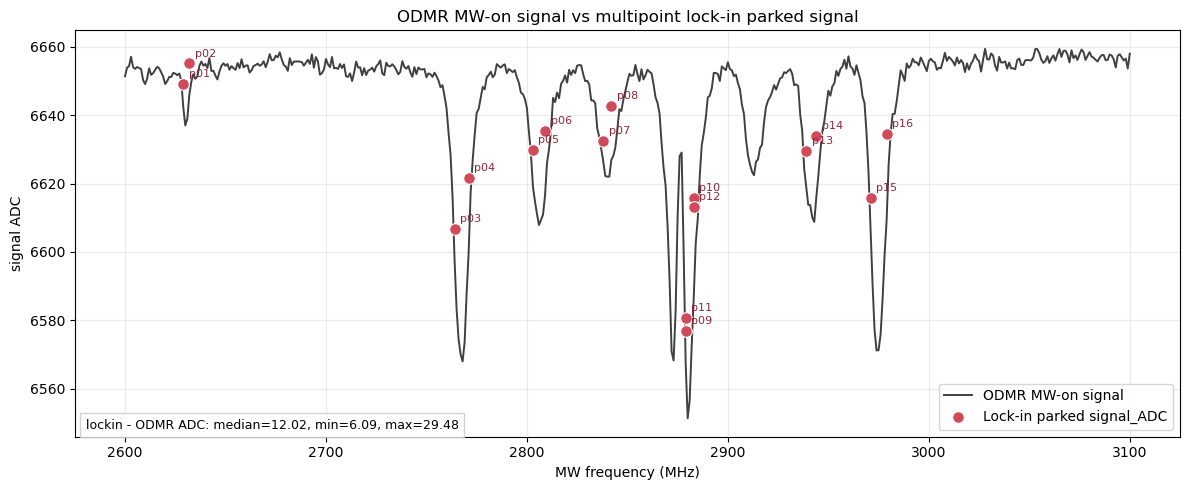

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    odmr["frequency_MHz"],
    odmr["photoluminescence_mw_on_ADC"],
    color="0.25",
    linewidth=1.4,
    label="ODMR MW-on signal",
)

ax.scatter(
    lockin_points["frequency_MHz"],
    lockin_points["lockin_signal_ADC"],
    s=70,
    color="#d1495b",
    edgecolor="white",
    linewidth=0.8,
    zorder=3,
    label="Lock-in parked signal_ADC",
)

for _, point in lockin_points.iterrows():
    ax.annotate(
        point["peak"].replace("peak_", "p"),
        (point["frequency_MHz"], point["lockin_signal_ADC"]),
        textcoords="offset points",
        xytext=(4, 5),
        fontsize=8,
        color="#8f2636",
    )

ax.set_title("ODMR MW-on signal vs multipoint lock-in parked signal")
ax.set_xlabel("MW frequency (MHz)")
ax.set_ylabel("signal ADC")
ax.grid(True, alpha=0.25)
ax.legend(loc="best")

summary = lockin_points["lockin_minus_odmr_ADC"].agg(["median", "min", "max"])
ax.text(
    0.01,
    0.02,
    f"lockin - ODMR ADC: median={summary['median']:.2f}, min={summary['min']:.2f}, max={summary['max']:.2f}",
    transform=ax.transAxes,
    fontsize=9,
    bbox={"facecolor": "white", "edgecolor": "0.8", "alpha": 0.9},
)

plt.tight_layout()
plt.show()